In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.read_csv("/home/aniket/Classical_ML_DL/Data/flipkard.csv")

In [3]:
df.shape

(80000, 25)

In [4]:
print("--- Unique Values per Column ---")
df.nunique()

--- Unique Values per Column ---


product_id            80000
product_name          48801
category                  8
brand                    15
seller                    8
seller_city               8
price                 79511
discount_percent          8
final_price           79378
rating                   41
review_count          39824
stock_available        1000
units_sold             5000
listing_date           2001
delivery_days            11
weight_g              73988
warranty_months           5
color                     8
size                      5
return_policy_days        5
is_returnable             2
payment_modes             4
shipping_weight_g     80000
product_score          9895
seller_rating           201
dtype: int64

In [5]:
category_shape = df['category'].value_counts()

# 3. Directly print the results
print("--- Row Counts Per Category ---")
print(category_shape.to_string())

# Optional: Print the total unique categories and total rows
print(f"\nTotal Unique Categories: {len(category_shape)}")
print(f"Total Rows in Dataset: {len(df)}")

--- Row Counts Per Category ---
category
Toys              10151
Beauty            10094
Fashion           10080
Electronics       10052
Sports             9985
Appliances         9971
Mobiles            9904
Home & Kitchen     9763

Total Unique Categories: 8
Total Rows in Dataset: 80000


In [6]:
target_category = "Toys"
df_toys = df[df['category'] == target_category]

In [7]:
df_toys.shape

(10151, 25)

In [8]:
from datetime import datetime

df_toys['listing_date'] = pd.to_datetime(df_toys['listing_date'])
today = datetime.now()
df_toys['months_old'] = (today.year - df_toys['listing_date'].dt.year) * 12 + (today.month - df_toys['listing_date'].dt.month)
df_toys = df_toys.drop('listing_date', axis=1)

In [9]:
df_toys.nunique()

product_id            10151
product_name           9461
category                  1
brand                    15
seller                    8
seller_city               8
price                 10141
discount_percent          8
final_price           10135
rating                   41
review_count           9193
stock_available        1000
units_sold             4357
delivery_days            11
weight_g              10058
warranty_months           5
color                     8
size                      5
return_policy_days        5
is_returnable             2
payment_modes             4
shipping_weight_g     10151
product_score          6331
seller_rating           201
months_old               66
dtype: int64

In [10]:
df_toys.drop(columns=["category","product_id","product_name","seller","seller_city","brand","payment_modes"], inplace=True)

In [11]:
df_toys.isnull().sum() 

price                    0
discount_percent         0
final_price              0
rating                   0
review_count             0
stock_available          0
units_sold               0
delivery_days            0
weight_g                 0
warranty_months          0
color                    0
size                  1683
return_policy_days       0
is_returnable            0
shipping_weight_g        0
product_score            0
seller_rating            0
months_old               0
dtype: int64

## Missing Value Test

In [12]:
import pandas as pd
from scipy import stats

# 1. Create a flag: True if 'size' is missing, False if it is present
df_toys['size_missing'] = df_toys['size'].isnull()

# 2. Identify numeric columns to compare against
# (We use your encoded numeric columns here)
numeric_cols = df_toys.select_dtypes(include=['number']).columns

print("--- MAR Detection (T-Test) ---")
for col in numeric_cols:
    if col == 'size': continue
    
    # Group the data based on whether 'size' is missing
    group_present = df_toys[df_toys['size_missing'] == False][col].dropna()
    group_missing = df_toys[df_toys['size_missing'] == True][col].dropna()
    
    # Run the T-test to compare the means
    t_stat, p_val = stats.ttest_ind(group_present, group_missing)
    
    if p_val < 0.05:
        print(f"Pattern Found! Missingness in 'size' depends on '{col}' (p={p_val:.4f})")
        print(f"Average {col} (Present): {group_present.mean():.2f}")
        print(f"Average {col} (Missing): {group_missing.mean():.2f}\n")

df_toys.drop(columns=['size_missing'], inplace=True)

--- MAR Detection (T-Test) ---
Pattern Found! Missingness in 'size' depends on 'delivery_days' (p=0.0413)
Average delivery_days (Present): 5.96
Average delivery_days (Missing): 6.13



## What This Means for Your Model
Since the missingness isn't random, simply deleting these rows would be a mistake because you would be biased toward only looking at items with faster delivery times.

Treat "Missing" as a piece of information itself. Instead of guessing a size or dropping the data, fill the blanks with a new category called "Unknown" before you perform your One-Hot Encoding. This allows your machine learning model to learn the "signal" that a missing size often relates to longer delivery windows.

In [13]:
# from sklearn.preprocessing import OneHotEncoder


# encoder = OneHotEncoder(drop='first', sparse_output=False)
# encoded_data = encoder.fit_transform(df_toys[['color']])
# new_cols = encoder.get_feature_names_out(['color'])
# encoded_df = pd.DataFrame(encoded_data, columns=new_cols, index=df_toys.index)
# df_toys = pd.concat([df_toys.drop(columns=['color']), encoded_df], axis=1)

In [14]:
# df_toys['size'] = df_toys['size'].fillna('a')
# encoder = OneHotEncoder(drop='first', sparse_output=False)
# encoded_data = encoder.fit_transform(df_toys[['size']])
# new_cols = encoder.get_feature_names_out(['size'])
# encoded_df = pd.DataFrame(encoded_data, columns=new_cols, index=df_toys.index)
# df_toys = pd.concat([df_toys.drop(columns=['size']), encoded_df], axis=1)

In [15]:
df_toys['is_returnable'] = df_toys['is_returnable'].map({True: 1, False: 0})

In [16]:
df_toys.dtypes

price                 float64
discount_percent        int64
final_price           float64
rating                float64
review_count            int64
stock_available         int64
units_sold              int64
delivery_days           int64
weight_g              float64
warranty_months         int64
color                     str
size                      str
return_policy_days      int64
is_returnable           int64
shipping_weight_g     float64
product_score         float64
seller_rating         float64
months_old              int32
dtype: object

## Correlation Plot 

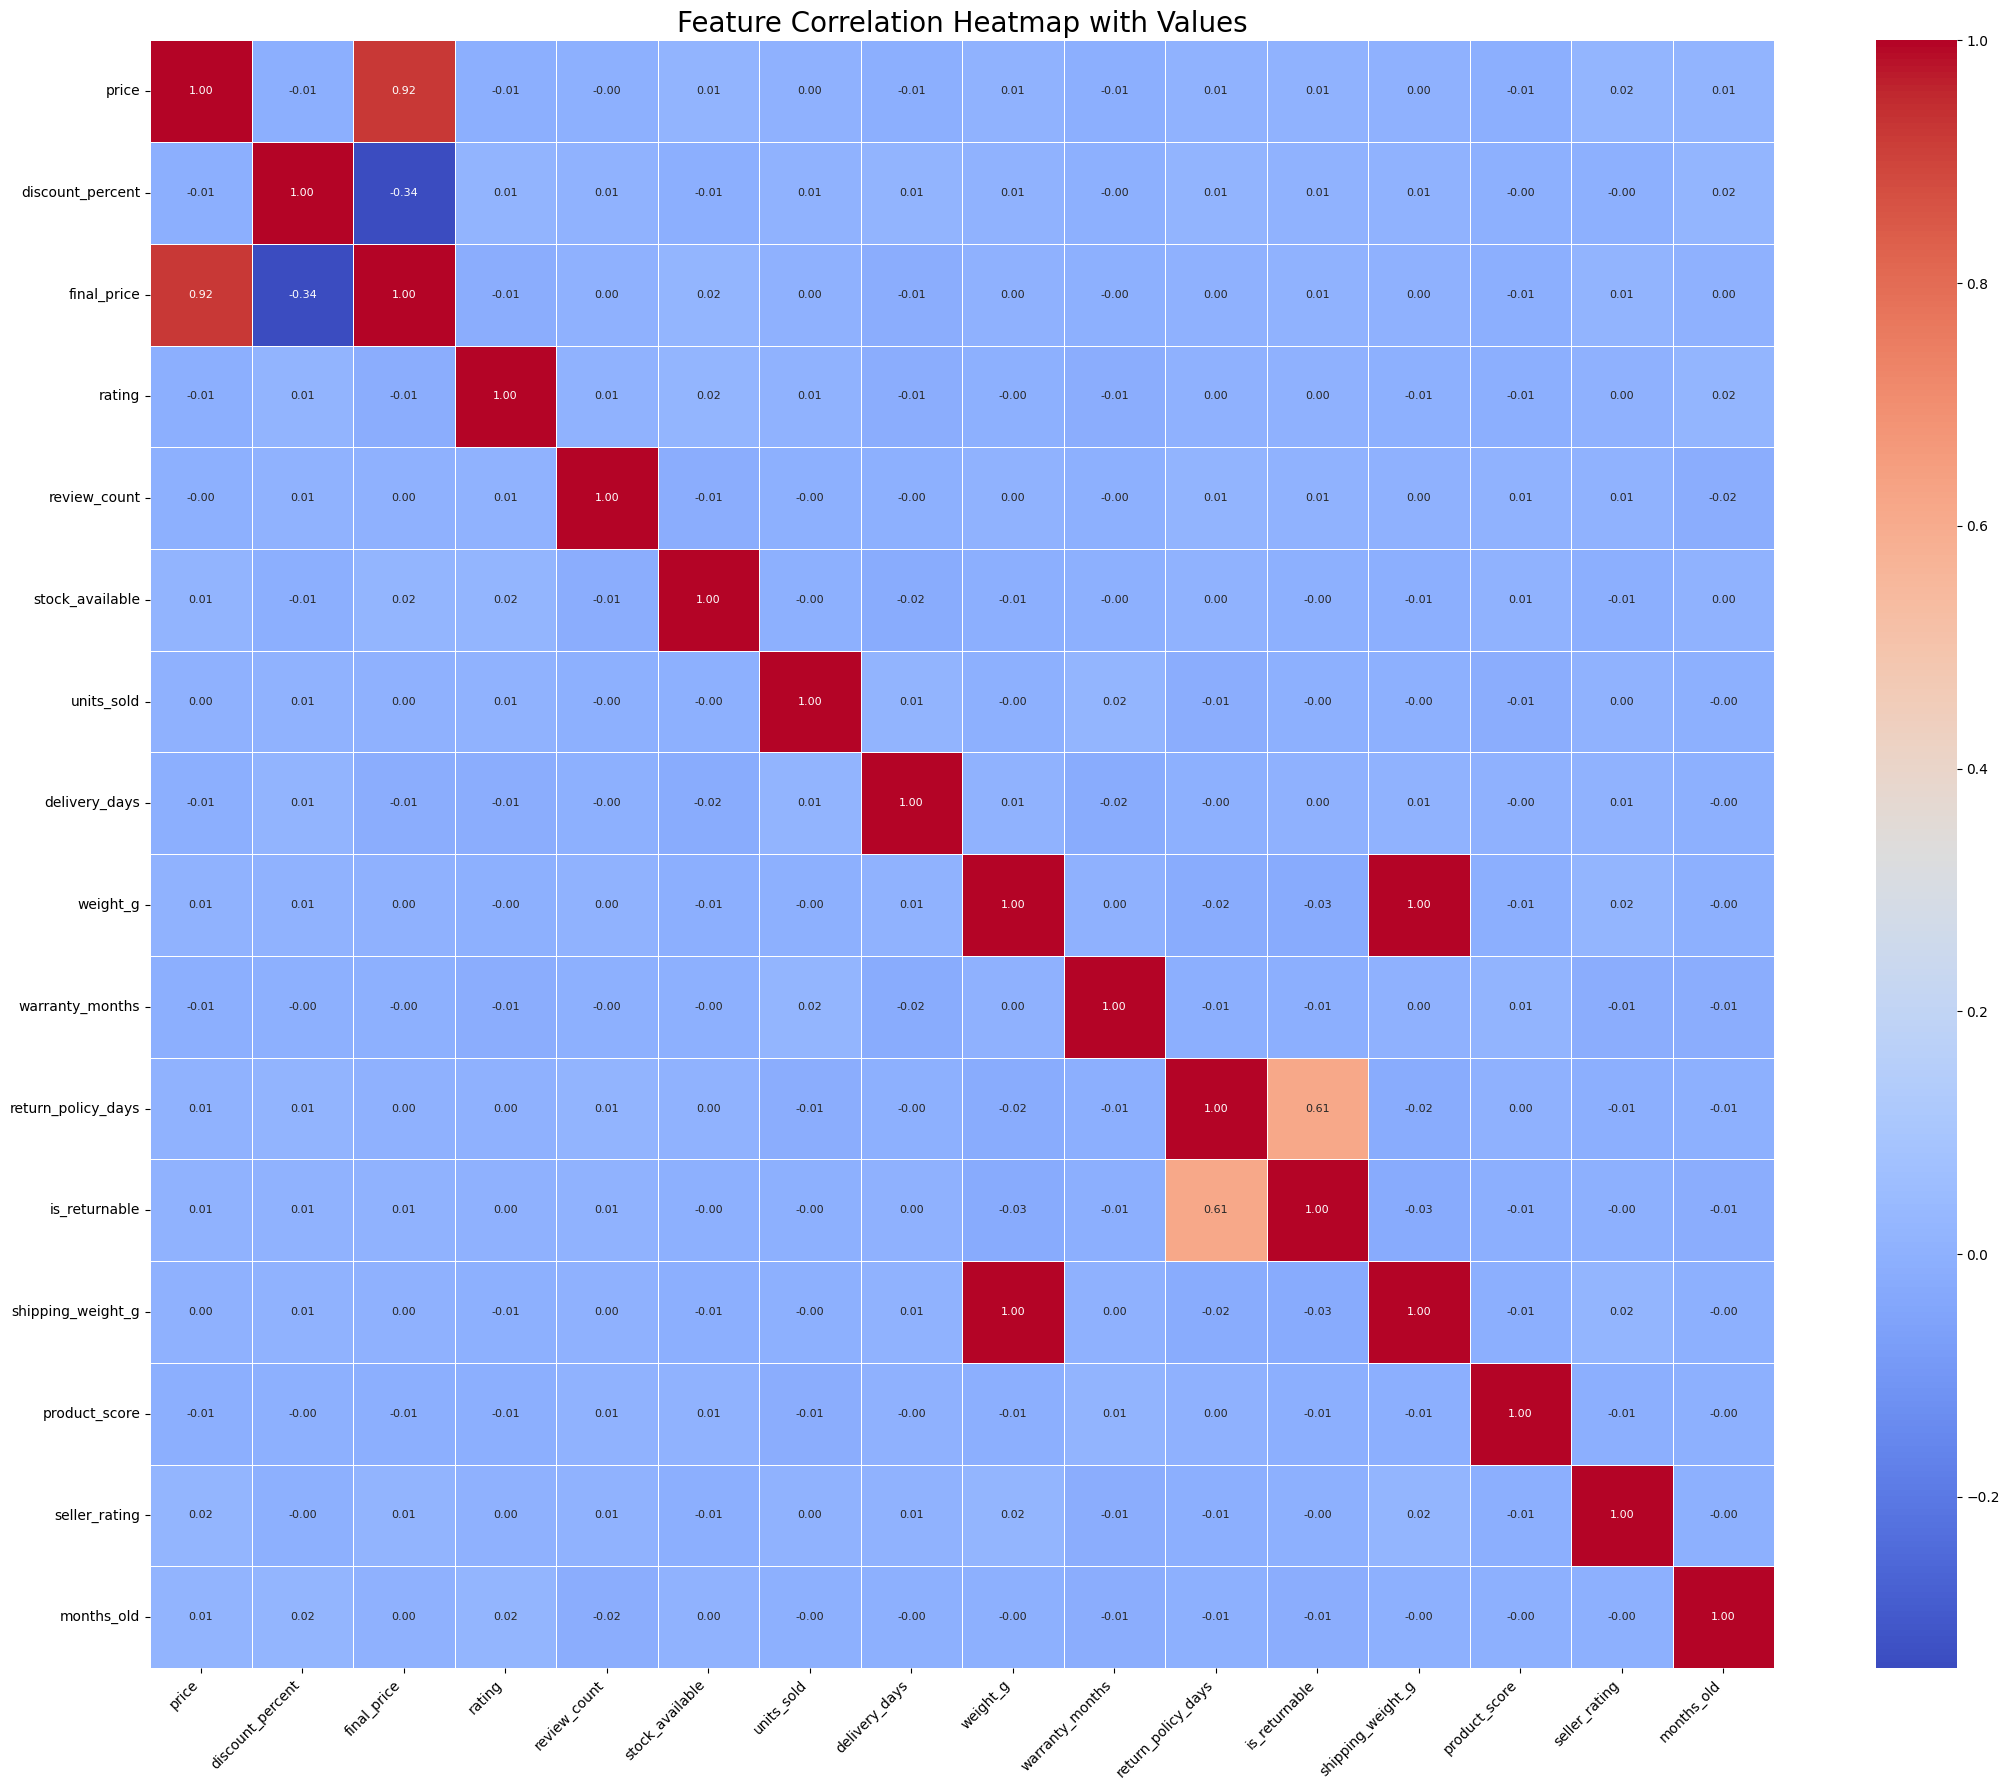

In [17]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 1. Filter for numeric columns
df_numeric = df_toys.select_dtypes(include=['number'])

# 2. Calculate correlation matrix
corr_matrix = df_numeric.corr()

# 3. Create the plot
# Increased figure size to accommodate the text labels
plt.figure(figsize=(22, 18)) 

# Key Changes:
# annot=True: This enables the numbers inside the boxes
# fmt=".2f": Rounds the numbers to 2 decimal places
# annot_kws={"size": 8}: Shrinks the font of the numbers so they fit in the grid
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5,
    annot_kws={"size": 8} 
)

plt.title("Feature Correlation Heatmap with Values", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 4. FORCED RENDER (The Jupyter Fix)
plt.savefig('correlation_with_values.png', bbox_inches='tight')
plt.close() 
display(Image('correlation_with_values.png'))

In [18]:
df_toys.drop(columns=['final_price', 'shipping_weight_g', 'size','color'], inplace=True)

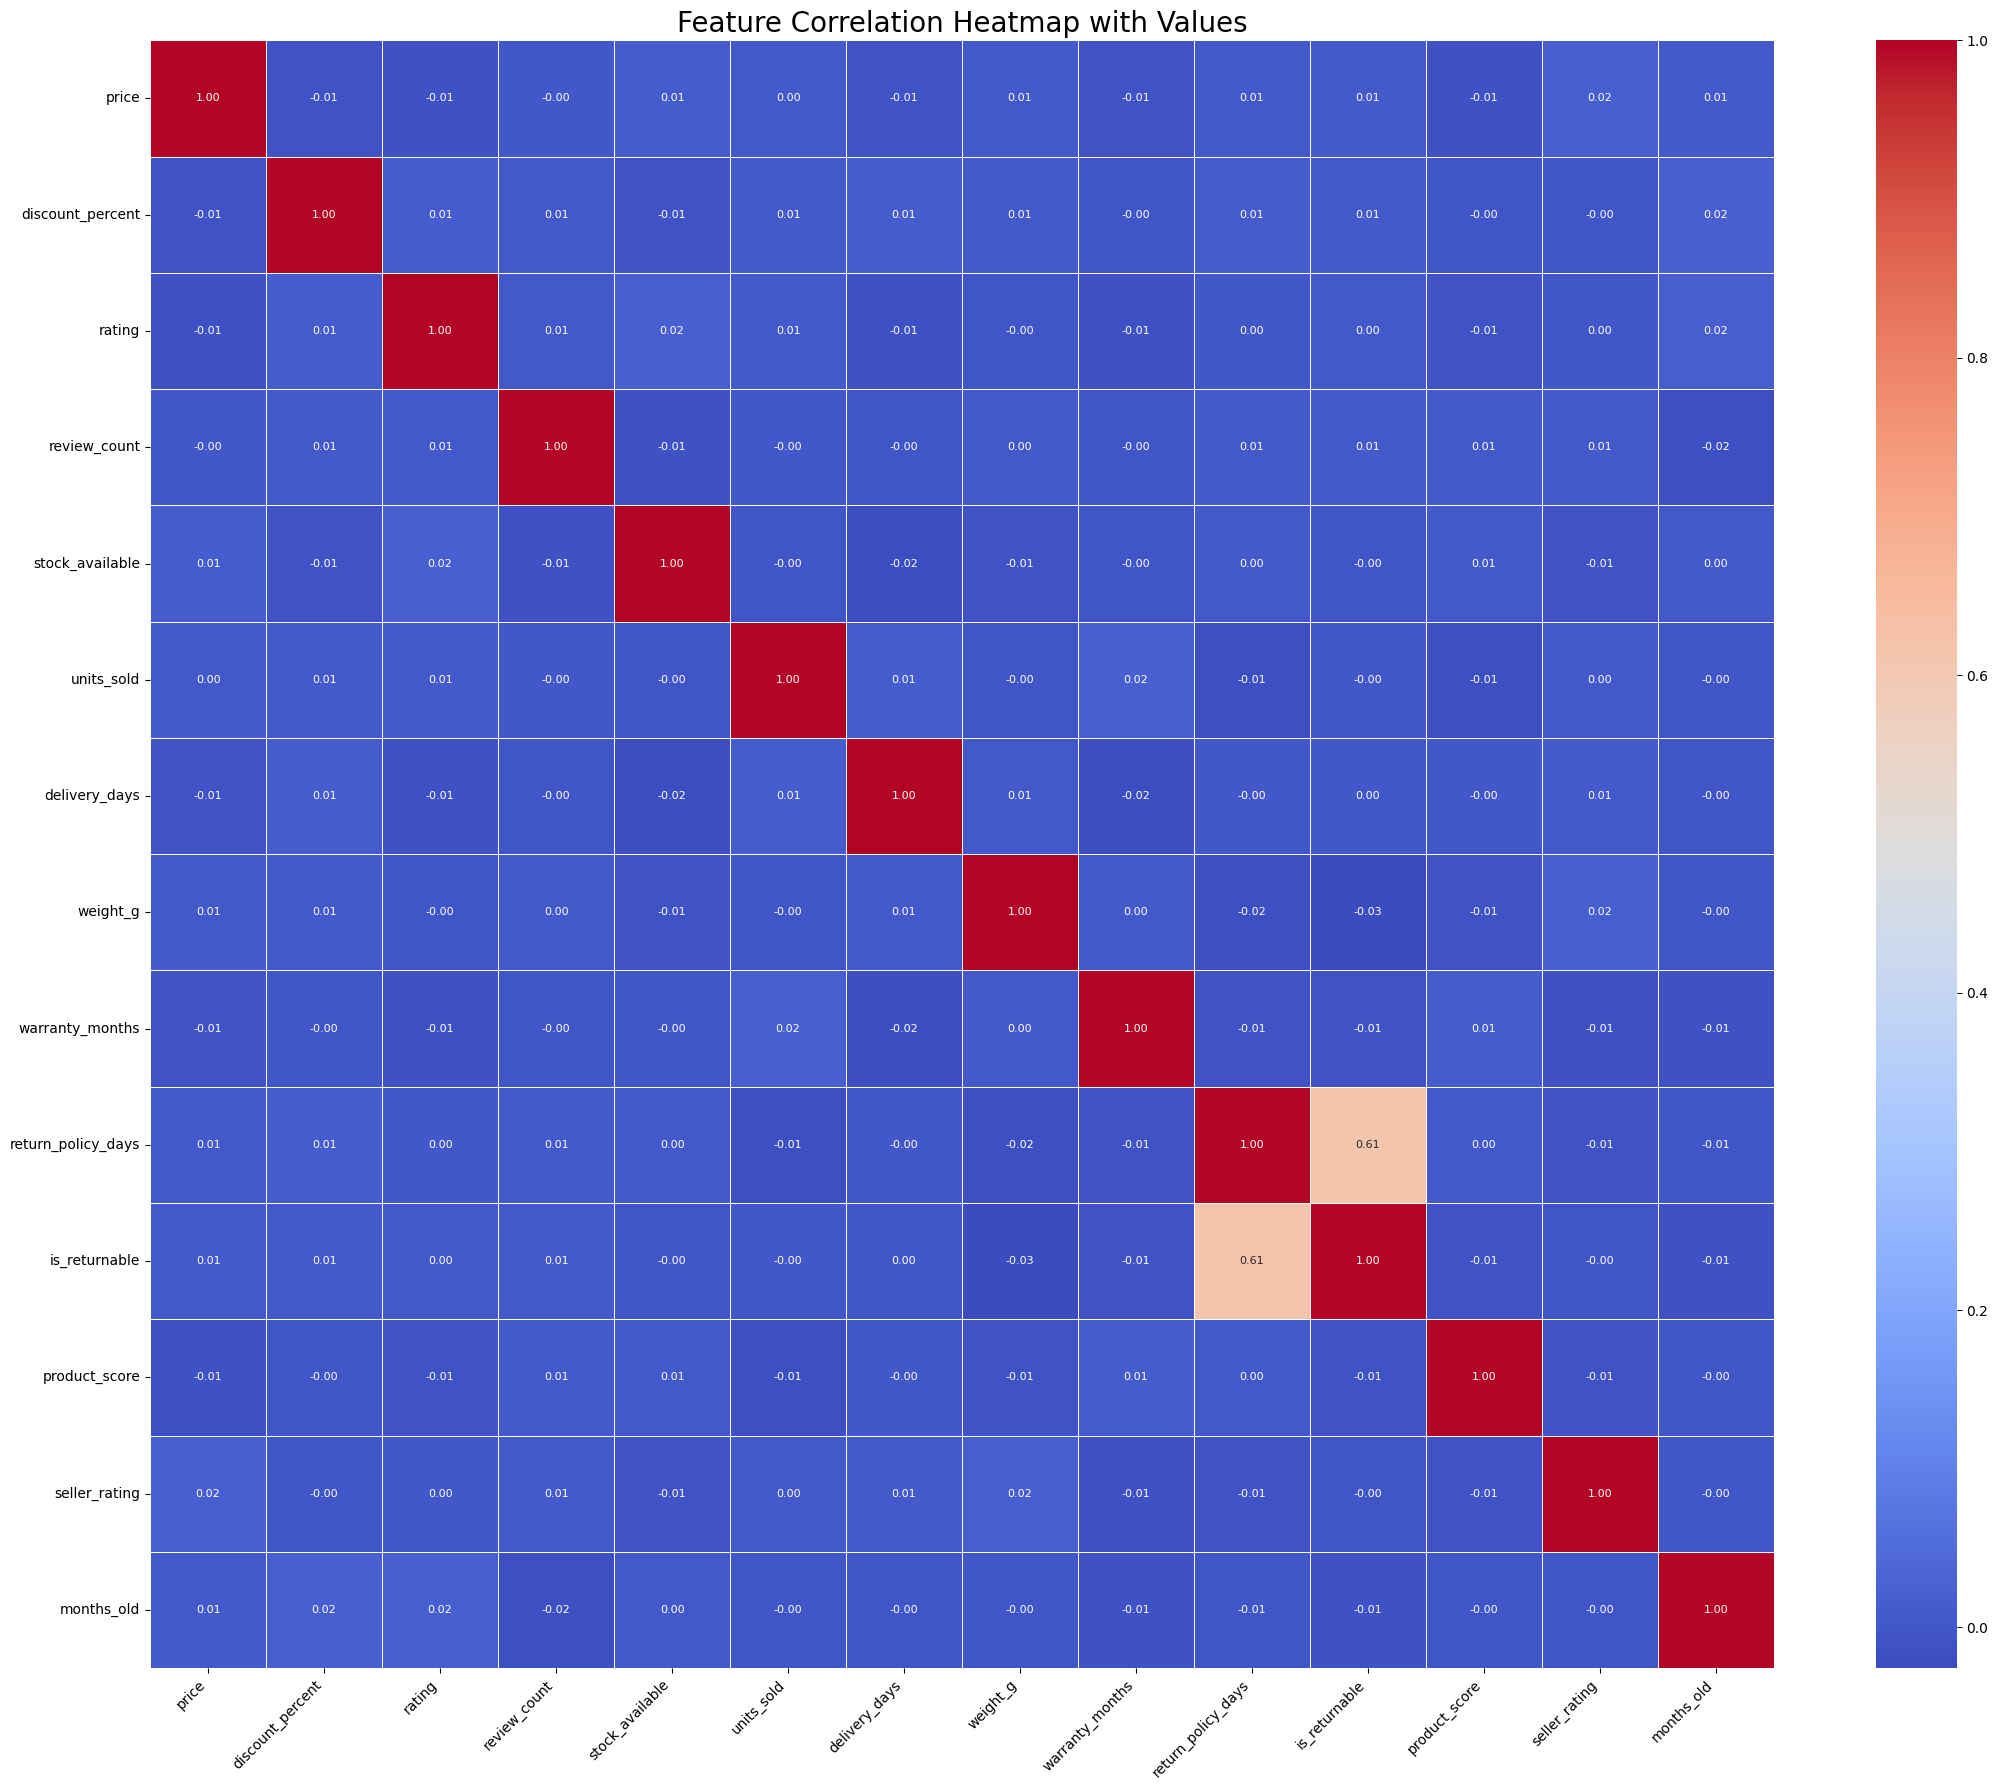

In [19]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 1. Filter for numeric columns
df_numeric = df_toys.select_dtypes(include=['number'])

# 2. Calculate correlation matrix
corr_matrix = df_numeric.corr()

# 3. Create the plot
# Increased figure size to accommodate the text labels
plt.figure(figsize=(22, 18)) 

# Key Changes:
# annot=True: This enables the numbers inside the boxes
# fmt=".2f": Rounds the numbers to 2 decimal places
# annot_kws={"size": 8}: Shrinks the font of the numbers so they fit in the grid
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5,
    annot_kws={"size": 8} 
)

plt.title("Feature Correlation Heatmap with Values", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 4. FORCED RENDER (The Jupyter Fix)
plt.savefig('correlation_with_values.png', bbox_inches='tight')
plt.close() 
display(Image('correlation_with_values.png'))

In [20]:
df_toys.head()

,price,discount_percent,rating,review_count,stock_available,units_sold,delivery_days,weight_g,warranty_months,return_policy_days,is_returnable,product_score,seller_rating,months_old
0,35547.34,15,1.9,26975,267,66,11,3038.23,36,30,1,6.78,3.28,49
3,33168.49,30,2.8,2000,509,1732,1,3644.81,24,0,0,1.38,3.45,81
8,26866.61,30,2.0,18219,960,718,2,857.60,24,7,1,8.17,3.96,100
11,1364.39,10,1.0,11991,172,3221,2,1635.52,12,15,1,4.29,4.84,50
41,46418.78,50,2.1,47777,575,594,3,1379.95,0,15,1,11.70,3.80,69


In [21]:
print(df_toys['rating'].max())
print(df_toys['rating'].min())

5.0
1.0


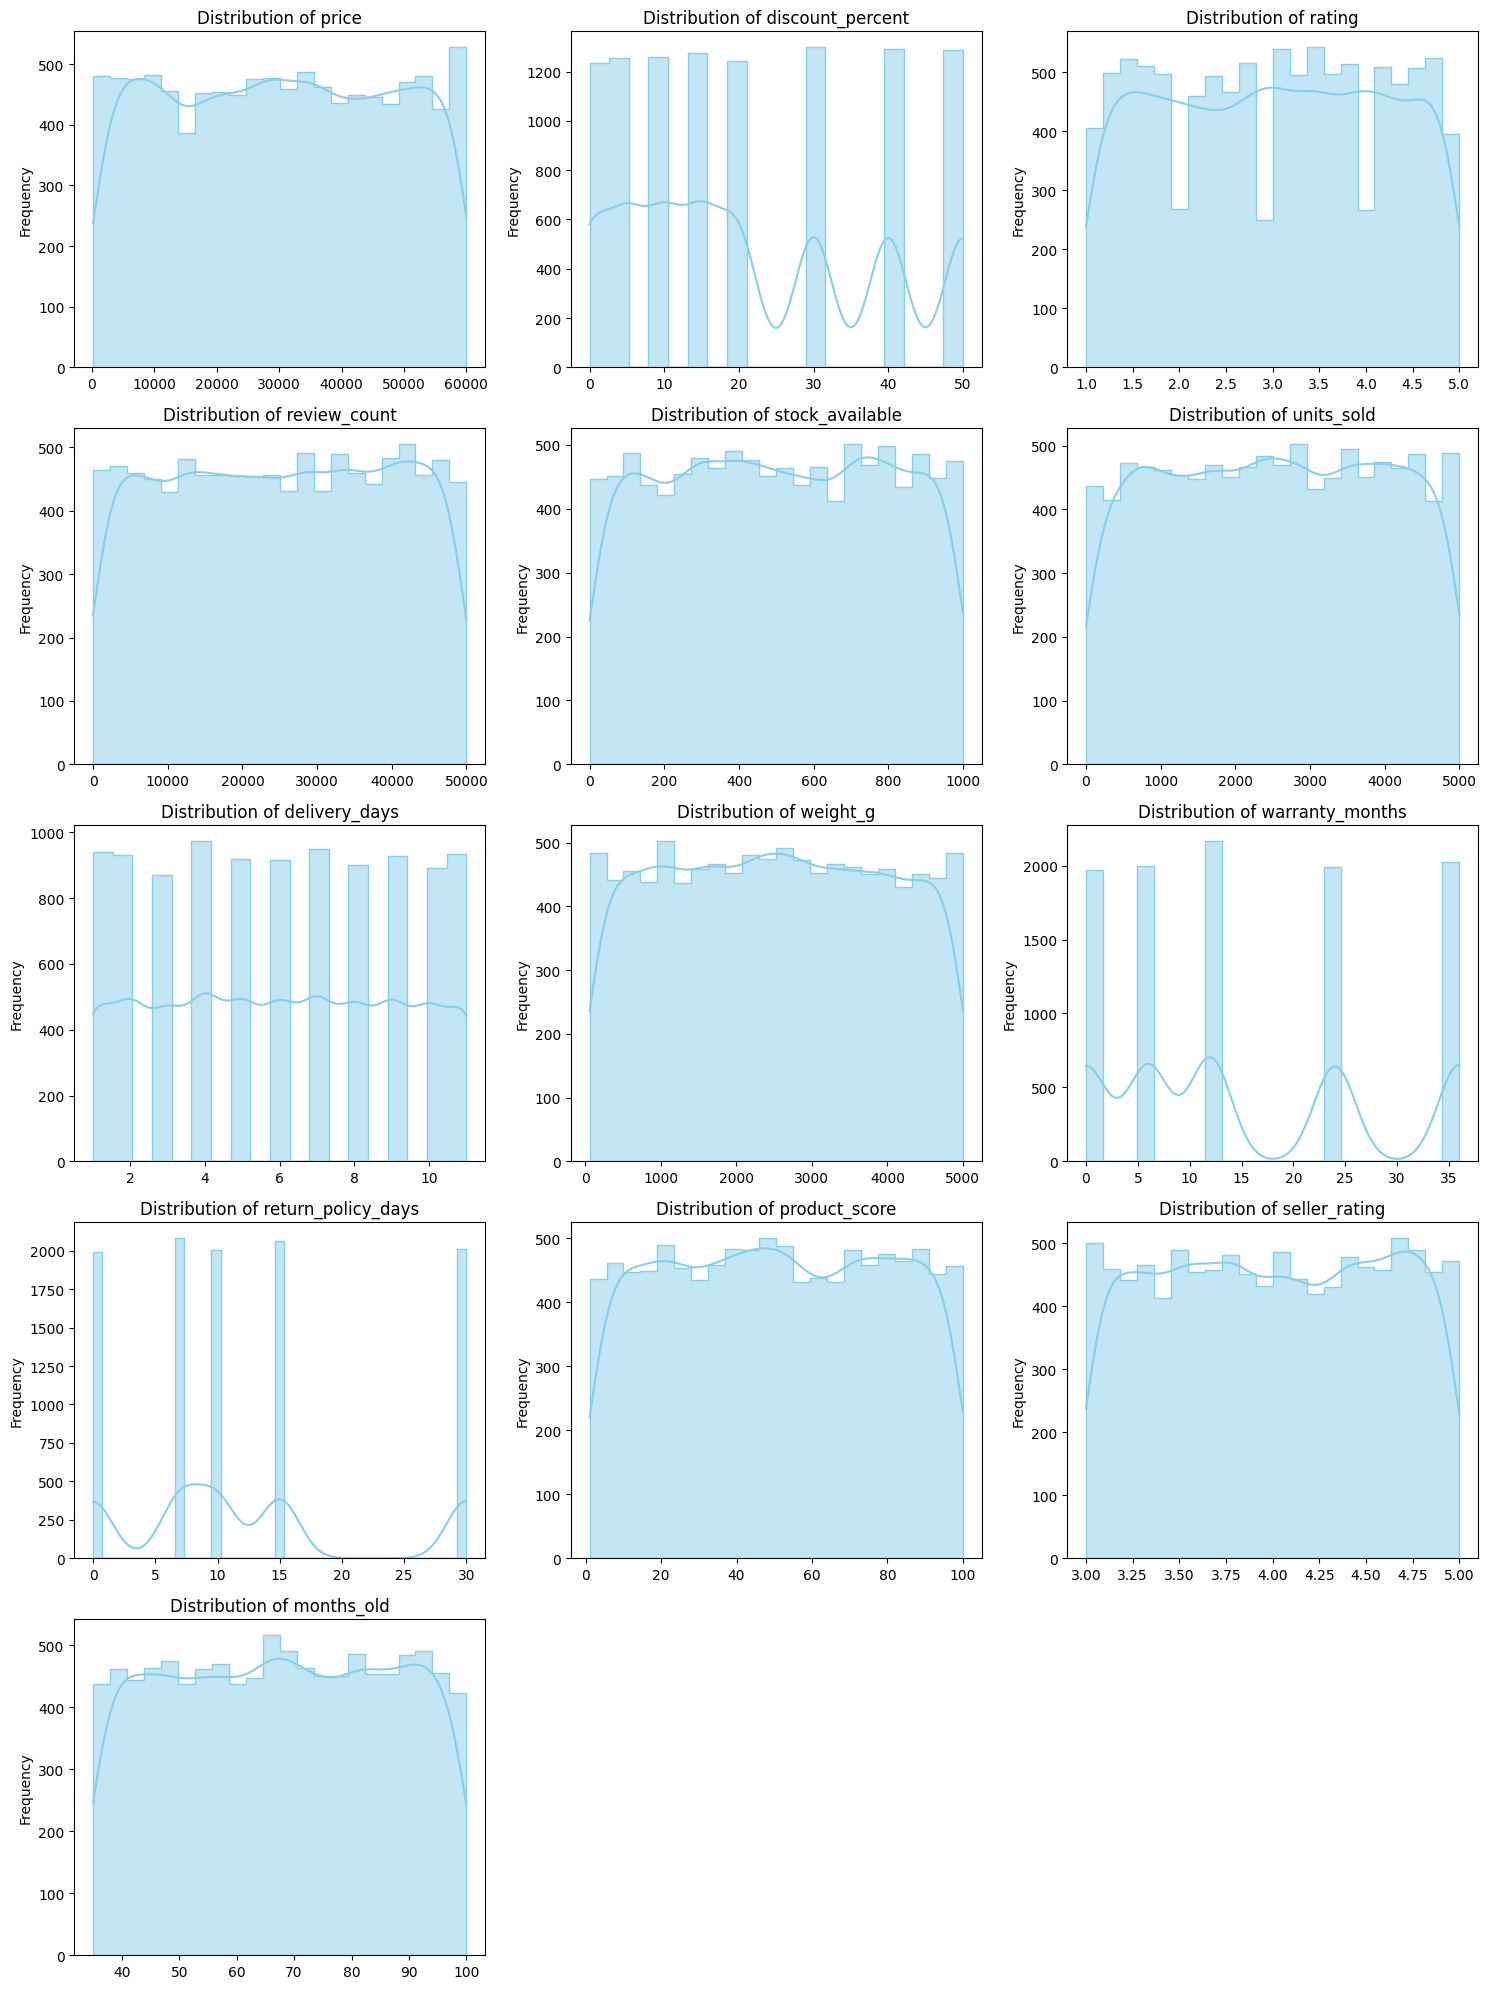

In [22]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Select numeric columns
numeric_cols = df_toys.select_dtypes(include=['number']).columns

# 2. Filter for columns with more than 2 unique values
# This skips binary data/one-hot columns (0 and 1)
cols_to_plot = [col for col in numeric_cols if df_toys[col].nunique() > 2]

# 3. Calculate grid size (how many rows/columns)
num_plots = len(cols_to_plot)
cols_per_row = 3
num_rows = math.ceil(num_plots / cols_per_row)

# 4. Create the plot grid
plt.figure(figsize=(15, num_rows * 4))

for i, col in enumerate(cols_to_plot):
    plt.subplot(num_rows, cols_per_row, i + 1)
    # Histogram + KDE (Kernel Density Estimate) curve
    sns.histplot(df_toys[col], kde=True, color='skyblue', element='step')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency')

# 5. Cleanup and Render
plt.tight_layout()
# Saving as a backup in case the notebook display hangs
plt.savefig('distribution_plots.png')
plt.show()

In [23]:
x = df_toys.drop(columns=['rating'])
y = df_toys['rating']
print(x.shape)
print(y.shape)

(10151, 13)
(10151,)


In [24]:
x.head()

,price,discount_percent,review_count,stock_available,units_sold,delivery_days,weight_g,warranty_months,return_policy_days,is_returnable,product_score,seller_rating,months_old
0,35547.34,15,26975,267,66,11,3038.23,36,30,1,6.78,3.28,49
3,33168.49,30,2000,509,1732,1,3644.81,24,0,0,1.38,3.45,81
8,26866.61,30,18219,960,718,2,857.60,24,7,1,8.17,3.96,100
11,1364.39,10,11991,172,3221,2,1635.52,12,15,1,4.29,4.84,50
41,46418.78,50,47777,575,594,3,1379.95,0,15,1,11.70,3.80,69


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import Image, display

# 3. MODELING (UPDATED FOR 100 EPOCHS)
# ---------------------------------------------------------
X = df_toys.drop(columns=['rating']) 
y = df_toys['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define model with exactly 100 estimators (epochs)
model = XGBRegressor(
    max_depth=6,
    learning_rate=0.1,         # Increased slightly so 100 epochs are more effective
    n_estimators=100,          # Set to exactly 100 as requested
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

# Fit with progress printed every 10 iterations
model.fit(
    X_train, y_train,
    # This set allows the model to calculate RMSE for both during training
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=10                # Prints results every 10 "epochs"
)

# 4. FINAL EVALUATION
# ---------------------------------------------------------
y_pred = model.predict(X_test)
print(f"\n--- Final Results after 100 Epochs ---")
print(f"Final R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Final RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

[0]	validation_0-rmse:1.15622	validation_1-rmse:1.16565
[10]	validation_0-rmse:1.12019	validation_1-rmse:1.16762
[20]	validation_0-rmse:1.08823	validation_1-rmse:1.17010
[30]	validation_0-rmse:1.05403	validation_1-rmse:1.17250
[40]	validation_0-rmse:1.02425	validation_1-rmse:1.17565
[50]	validation_0-rmse:0.99760	validation_1-rmse:1.17672
[60]	validation_0-rmse:0.97519	validation_1-rmse:1.18046
[70]	validation_0-rmse:0.94909	validation_1-rmse:1.18357
[80]	validation_0-rmse:0.92535	validation_1-rmse:1.18710
[90]	validation_0-rmse:0.90257	validation_1-rmse:1.19062
[99]	validation_0-rmse:0.88131	validation_1-rmse:1.19162

--- Final Results after 100 Epochs ---
Final R² Score: -0.0475
Final RMSE: 1.1916
